<a href="https://colab.research.google.com/github/tasneemsk500/Algthms_Machine_Learning_Practice/blob/main/Tasneem_Shahnewaz_Khan_A2_Linear_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A2 - Linear Model

CAP4611-26SummerC001

Tasneem Shahnewaz Khan

## A. Load Data and Perform General EDA [14 pts]
### I. Import libraries: pandas, numpy, matplotlib (set %matplotlib inline), matplotlib’s pyplot, seaborn, missingno, scipy’s stats, sklearn (1 pt)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno

### II. Load the dataset into a DataFrame and print the number of rows and columns. (1 pt)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load the data
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/A2 Linear Models/gaming_platform.csv")

#print the nuumber of rows and columns
print(df.shape)

(500, 8)


### III. Display the first 5 and last 5 rows. (1 pt)

In [ ]:
#first 5 rows
print(df.head(5))

           Gamertag        Country         Account_ID  Avg_Weekly_Play_Time  \
0  CrimsonBunny8837  United States  76561198000032045             35.497268   
1    HappyPixel2394    South Korea  76561198000059463             32.926272   
2      TinyNova2890         Mexico  76561198000909768             34.000915   
3     BlueDragon708  United States  76561198000786712             35.305557   
4        TinyWizard          India  76561198000121548             34.330673   

   Time_on_Mobile_Client  Time_on_Desktop_Client  Years_As_Player  \
0              13.655651               40.577668         4.582621   
1              12.109461               38.268959         3.164034   
2              12.330278               38.110597         4.604543   
3              14.717514               37.721283         3.620179   
4              13.795189               38.536653         4.946308   

   Annual_Spending  
0       588.951054  
1       393.204933  
2       488.547505  
3       582.852344  
4    

In [ ]:
#last 5 rows
print(df.tail(5))

              Gamertag    Country         Account_ID  Avg_Weekly_Play_Time  \
495     NeonPlayer4521      Japan  76561198000368132             34.237660   
496        HappyFalcon    Belgium  76561198000046743             35.702529   
497  SilverPenguin3927      Spain  76561198000534794             33.646777   
498   PixelPhoenix5083  Argentina  76561198000551910             34.322501   
499      CozyPenguinTV    Germany  76561198000917665             34.715981   

     Time_on_Mobile_Client  Time_on_Desktop_Client  Years_As_Player  \
495              14.566160               37.417985         4.246573   
496              12.695736               38.190268         4.076526   
497              12.499409               39.332576         5.458264   
498              13.391423               37.840086         2.836485   
499              13.418808               36.771016         3.235160   

     Annual_Spending  
495       574.847438  
496       530.049004  
497       552.620145  
498       45

### IV. Call .describe() on the DataFrame. In a markdown cell, interpret any two numerical variables in your own words. (1 pt)

In [ ]:
#statistical description
print(df.describe())

         Account_ID  Avg_Weekly_Play_Time  Time_on_Mobile_Client  \
count  5.000000e+02            500.000000             500.000000   
mean   7.656120e+16             34.053194              13.052488   
std    2.891219e+05              0.992563               0.994216   
min    7.656120e+16             30.532429               9.508152   
25%    7.656120e+16             33.341822              12.388153   
50%    7.656120e+16             34.082008              12.983231   
75%    7.656120e+16             34.711985              13.753850   
max    7.656120e+16             37.139662              16.126994   

       Time_on_Desktop_Client  Years_As_Player  Annual_Spending  
count              500.000000       500.000000       500.000000  
mean                38.060445         4.033462       500.314038  
std                  1.010489         0.999278        79.314782  
min                 34.913847         0.769901       257.670582  
25%                 37.349257         3.430450       446.

Avg_Weekly_Play_Time
The above variable calculates the average hours each players spend playing in all the games weekly. This is tracked by the platform where the players spend time playing in.

Time_on_Mobile_Client
The above variable calculates the average minutes each players spend when they're using the platform's mobile companion application for each session. This is tracked by the platform as well.

### V. Perform a missing value analysis. (1 pt)

In [ ]:
#check if all are numeric types just to make sure
print(df.dtypes)

Gamertag                   object
Country                    object
Account_ID                  int64
Avg_Weekly_Play_Time      float64
Time_on_Mobile_Client     float64
Time_on_Desktop_Client    float64
Years_As_Player           float64
Annual_Spending           float64
dtype: object


In [ ]:
#counts the missing values in descending order
nulls = df.isnull().sum().to_frame('nulls') #sum up nulls and make a df\n
# print(nulls)

nulls.sort_values("nulls", inplace = True, ascending = False) #sort it by descending order
for index, row in nulls.iterrows(): #print it in well formatted way
  print(index, row[0])

Gamertag 0
Country 0
Account_ID 0
Avg_Weekly_Play_Time 0
Time_on_Mobile_Client 0
Time_on_Desktop_Client 0
Years_As_Player 0
Annual_Spending 0


/tmp/ipykernel_17978/207533429.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(index, row[0])


From the above, we can see that none of the columns are missing.

### VI. Generate the following scatter plots and answer the questions in markdown cells:
#### 1. Annual_Spending vs. Time_on_Desktop_Client

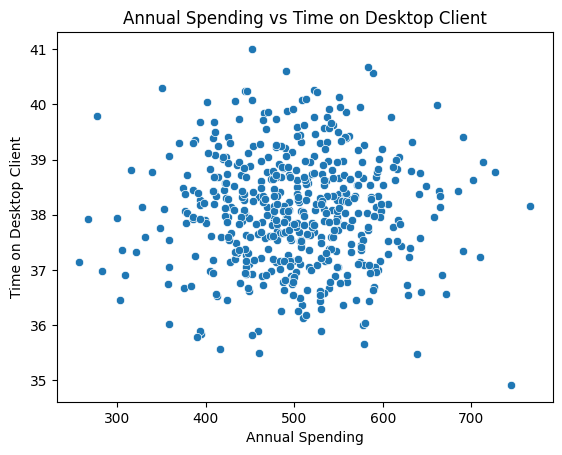

In [ ]:
plt.title("Annual Spending vs Time on Desktop Client")
sns.scatterplot(data=df, x='Annual_Spending', y='Time_on_Desktop_Client')
plt.xlabel("Annual Spending")
plt.ylabel("Time on Desktop Client")
plt.show()

#### 2. Annual_Spending vs. Time_on_Mobile_Client

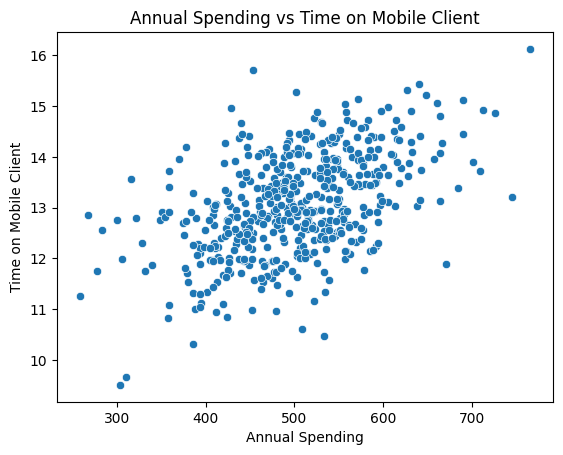

In [ ]:
plt.title("Annual Spending vs Time on Mobile Client")
sns.scatterplot(data=df, x='Annual_Spending', y='Time_on_Mobile_Client')
plt.xlabel("Annual Spending")
plt.ylabel("Time on Mobile Client")
plt.show()

#### 3. Years_As_Player vs. Time_on_Mobile_Client

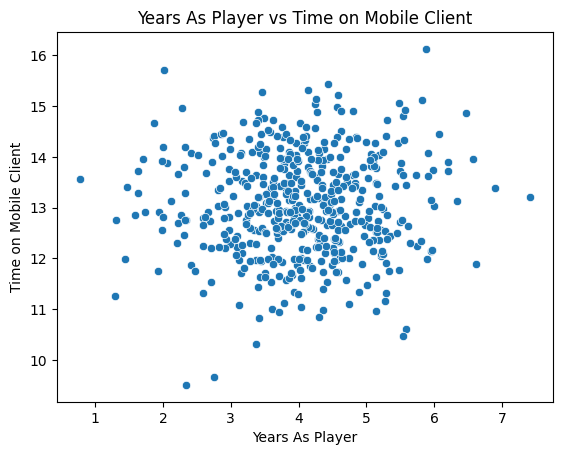

In [ ]:
plt.title("Years As Player vs Time on Mobile Client")
sns.scatterplot(data=df, x='Years_As_Player', y='Time_on_Mobile_Client')
plt.xlabel("Years As Player")
plt.ylabel("Time on Mobile Client")
plt.show()

### 4. A seaborn pairplot of all numerical features. Based on the pairplot, which feature appears to have the strongest relationship with Annual_Spending?

<Figure size 1000x700 with 0 Axes>

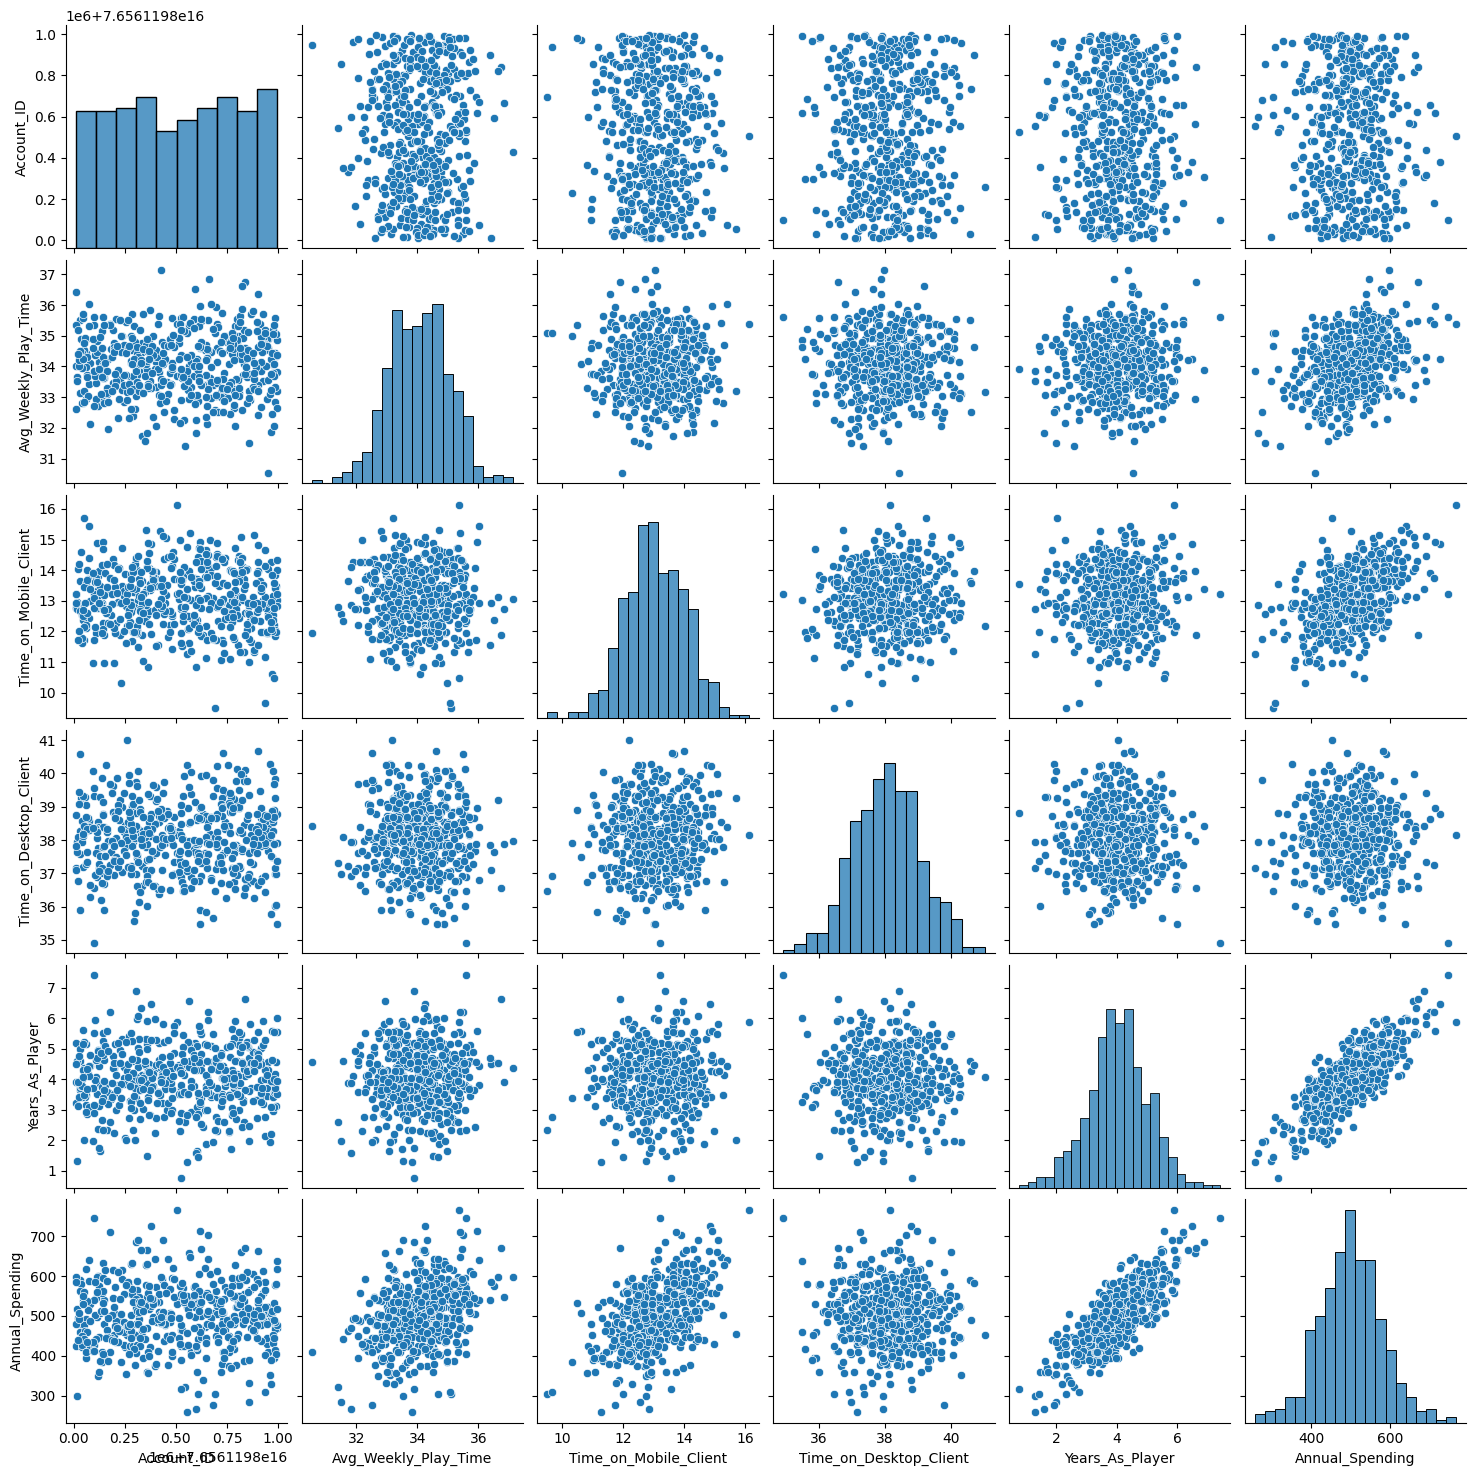

In [ ]:
plt.figure(figsize = (10, 7)) #set the size
sns.pairplot(df)
plt.show()

**According to these plots, the column with the strongest correlation to Annual_Spending is Years_As_Player. (1 pt for this)**

From the above pairplot, we can observe that Annual_Spending is positively corelated to Years_As_Player

#### 5. A seaborn heatmap (annot=True) of the correlation matrix. Based on the correlation matrix, are there any columns that could potentially be removed? Which feature appears most strongly related to Annual_Spending?

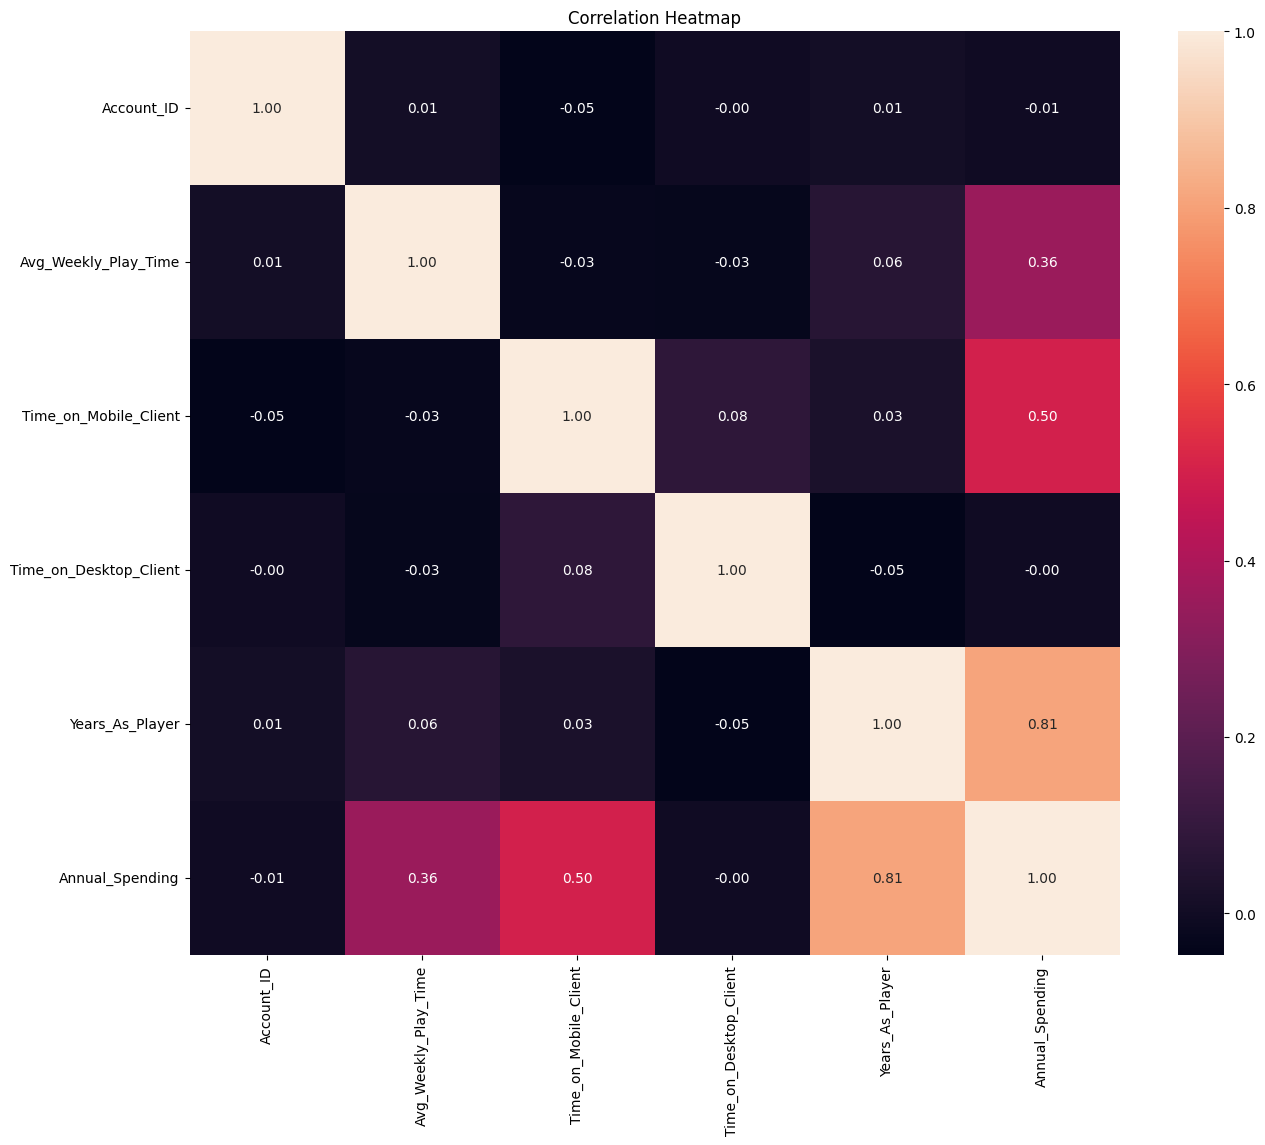

In [ ]:
#Create a numeric feature variable
num_features = df.select_dtypes(include = [np.number])
num_features.columns
correlation = num_features.corr()

#Plot the heatmap
plt.figure(figsize = (15, 12))
sns.heatmap(correlation, annot=True, xticklabels=num_features.columns, yticklabels=num_features.columns, fmt='.2f') #use at least 2 decimal value to see the correlations

plt.title('Correlation Heatmap')

plt.show()

From the above heatmap, we can easily remove Account_ID as it's in between -0.05 and 0.05 range in relative to the target value, Annual_Spending. Apart from that other non-numeric datas that are not accounted for like Gamertag and Country should be removed.

From the above heatmap, we can observe that the strongest corelated feature is Years_As_Player with 0.81 score in relative to the target feature Annual_Spending.

#### 6. A scatter plot of the most correlated feature vs. Annual_Spending.


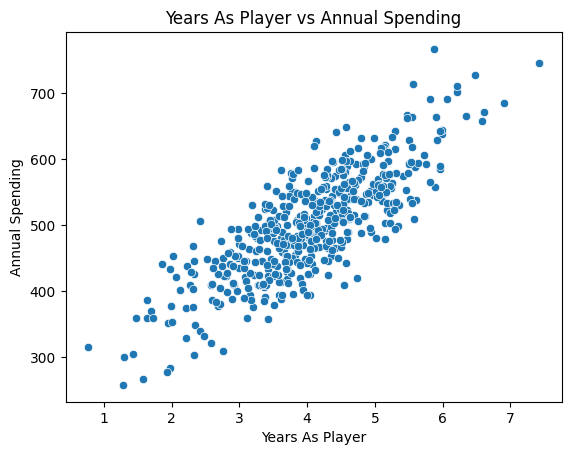

In [ ]:
plt.title("Years As Player vs Annual Spending")
sns.scatterplot(data=df, x='Years_As_Player', y='Annual_Spending')
plt.xlabel("Years As Player")
plt.ylabel("Annual Spending")
plt.show()

## B. Feature Selection and Pre-processing [4 pts]

### I. Based on your EDA, missing value analysis, and understanding of regression models, remove any features that are not useful for prediction.

*Important: Do not remove Time_on_Desktop_Client as it is central to the business question.*

From the above EDA, I've decided to remove the non-numeric features like Gamertag and Country as these don't contribute to the target value prediction

I removed the the Account ID as it only identifies the individual customers

I've kept:
Time_on_Desktop_Client
Time_on_Mobile_Client
Avg_Weekly_Play_Time
Years_As_Player

In [ ]:
#remove those as listed from A VI,5 excluding the Time_on_Desktop
df_clean = df.drop(columns=['Account_ID', 'Gamertag', 'Country'])

## C. Train/Test Split and Scaling [8 pts]

### I. Use sklearn's train_test_split to split the dataset into training and testing sets. The test set should contain 30% of the instances, and you must use random_state 101.

In [ ]:
#import from the libraries
from sklearn.model_selection import train_test_split

#Separate the target from the list of features
X= df_clean.drop('Annual_Spending', axis=1)
y = df_clean['Annual_Spending']

#Split the train, test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

### II. For a lot of regression techniques, scaling the dataset is important. As such, scale the feature matrices (X_train and X_test) using StandardScaler from sklearn. Fit the scaler only on the training data and then use it to transform both the training and testing sets. Do not scale y_train or y_test.

In [ ]:
#import from the libraries
from sklearn.preprocessing import StandardScaler

#scale them up
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) #Fit the scaler only on the training data and transform it
X_test = scaler.transform(X_test) #transform the test data

## D. Helper Function: evaluate_model() [10 pts]

### Many sections below require the same evaluation steps. To avoid repetition, implement a reusable function before proceeding.
Your function must:

i. Calculate and print the MAE, MSE, RMSE, and R² values using sklearn.metrics. For help on how to implement this, you may refer to the documentation on sklearn's metrics.

ii. Generate a scatter plot with y_test on the x-axis and y_pred on the y-axis, labelled with the model name.

In [ ]:
def evaluate_model(y_test, y_pred, model_name="Model"):

  #import libraries
  from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

  #Evaluate the metrics
  mae = mean_absolute_error(y_test, y_pred) #MAE
  mse = mean_squared_error(y_test, y_pred) #MSE
  rmse = np.sqrt(mse)  #square root of mse = RMSE
  r2 = r2_score(y_test, y_pred) #r2_score

  #Display the metrices, for me 4 decimal places
  print(f"MAE: {mae:.4f}")
  print(f"MSE: {mse:.4f}")
  print(f"RMSE: {rmse:.4f}")
  print(f"R²: {r2:.4f}")

  #Generate the scatter plot
  plt.figure(figsize=(10, 7))
  plt.scatter(y_test, y_pred, alpha=0.6, s=50)
  plt.xlabel("Actual value: (y_test)")
  plt.ylabel("Predicted value: (y_pred)")
  plt.title(f"{model_name}: Actual vs Predicted")
  plt.show()

## E. Linear Regression (sklearn) [21 pts]

### I. Train a LinearRegression model. An example is provided in the linear regression slides/Google Colab links in Webcourses.

In [ ]:
# from the google link
# Verification with sklearn linearRegression
from sklearn.linear_model import LinearRegression
lr=LinearRegression()    # Object.
lr.fit(X_train, y_train) # fit method.

LinearRegression()

### II. Print the intercept and all feature coefficients.

In [ ]:
# Print obtained theta values.
print("Best value of theta in array format:",lr.intercept_,lr.coef_,sep='\n')

print("\nIntercept: ", lr.intercept_)

#extract the col names
col_names = df_clean.drop('Annual_Spending', axis=1).columns

##Use for loop to see which theta value represents what. need to make a copy of it in section C
print("\nValue of theta in list format:")
for col, coef in zip(col_names, lr.coef_):
  print(f"{col}: {coef:.6f}")

#print the absolute coefficient values
# print("\nAbsolute coeficient values")
# for col, coef in zip(col_names, lr.coef_):
#   coef = np.abs(coef)
#   print(f"{col}: {coef:.6f}")

Best value of theta in array format:
499.72311649168824
[26.04265125 36.67425683  0.18503853 60.20236045]

Intercept:  499.72311649168824

Value of theta in list format:
Avg_Weekly_Play_Time: 26.042651
Time_on_Mobile_Client: 36.674257
Time_on_Desktop_Client: 0.185039
Years_As_Player: 60.202360


### III. Predict on the test set and call evaluate_model().

MAE: 7.2281
MSE: 79.8131
RMSE: 8.9338
R²: 0.9890


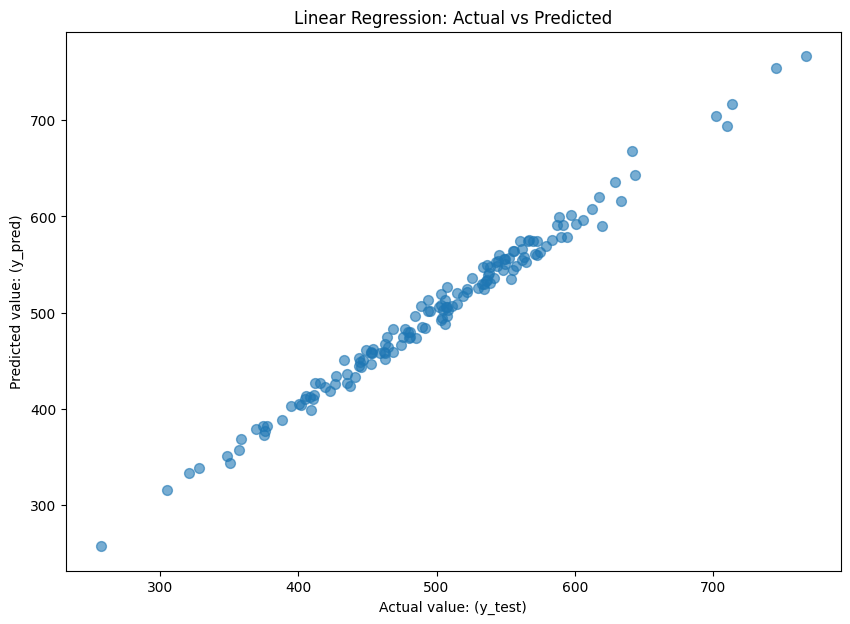

In [ ]:
#predict.
# print("predicted value:",lr.predict(x_sample),sep='\n')

#assign the predicted to y_pred
y_pred = lr.predict(X_test)

#call our function
evaluate_model(y_test, y_pred, model_name="Linear Regression")

### IV. Interpretation (markdown): Based on the coefficients, which feature appears to have the strongest effect on Annual_Spending? What does this imply from a business perspective?

From the E (ii) coefficient evaluation, it can be seen that Years_As_Player has the strongest effect on Annual_Spending due to very high theta value.

From a business perspective, we need to work on this feature and improvise it as it the most important driver or influencer to reatain customers and generate maximum revenue. For instance, they can implement benefits for long terms players to motivate them to stay longer with the platform.

## F. Normal Equation [23 pts]
Implement the Normal Equation using NumPy. You will need to handle matrix operations manually (to_numpy(), reshape, transpose, adding a bias column, etc.). I would recommend looking at the Google Colab we have seen in class and comparing the shape of the X and y sets and that of their data to help you during this process. The code and discussion shared in the slides should also be helpful to you.

### I. Implement the Normal Equation and compute the best_theta values from the training set.

In [ ]:
#check y
print(y_train)

202    444.965627
428    557.298141
392    550.131573
86     488.379306
443    562.516532
          ...    
63     484.159721
326    506.230068
337    441.002748
11     523.337405
351    534.396554
Name: Annual_Spending, Length: 350, dtype: float64


In [ ]:
#check y shape
print(y_train.shape)

(350,)


In [ ]:
#reshape
y_train_new = y_train.values.reshape(350,1)
print(y_train_new.shape)

(350, 1)


In [ ]:
# Adding x0=1 to each instance
X_train_new = np.c_[np.ones(len(X_train)), X_train]

# Using Normal Equation. compute the theta value
theta_best_values = np.linalg.inv(X_train_new.T.dot(X_train_new)).dot(X_train_new.T).dot(y_train_new)

# Display best values obtained.
# print(theta_best_values)



### II. Display theta values. Think about how do they compare to the sklearn LinearRegression coefficients; no need to write about it.

In [ ]:
# feature names
feature_names = df_clean.drop('Annual_Spending', axis=1).columns

#Intercept
print(f"Intercept: {theta_best_values[0][0]:.6f}\n")

#for all columns
print("Feature Coefficients:")
for i, (feat, coef) in enumerate(zip(feature_names, theta_best_values[1:]), 1):
    print(f"{feat}: {coef[0]:.6f}")

# Display best values obtained.
print("\nTheta values: \n",theta_best_values)

Intercept: 499.723116

Feature Coefficients:
Avg_Weekly_Play_Time: 26.042651
Time_on_Mobile_Client: 36.674257
Time_on_Desktop_Client: 0.185039
Years_As_Player: 60.202360

Theta values: 
 [[4.99723116e+02]
 [2.60426512e+01]
 [3.66742568e+01]
 [1.85038528e-01]
 [6.02023604e+01]]


### III. Prepare the test set, perform the prediction, and call evaluate_model().

MAE: 7.2281
MSE: 79.8131
RMSE: 8.9338
R²: 0.9890


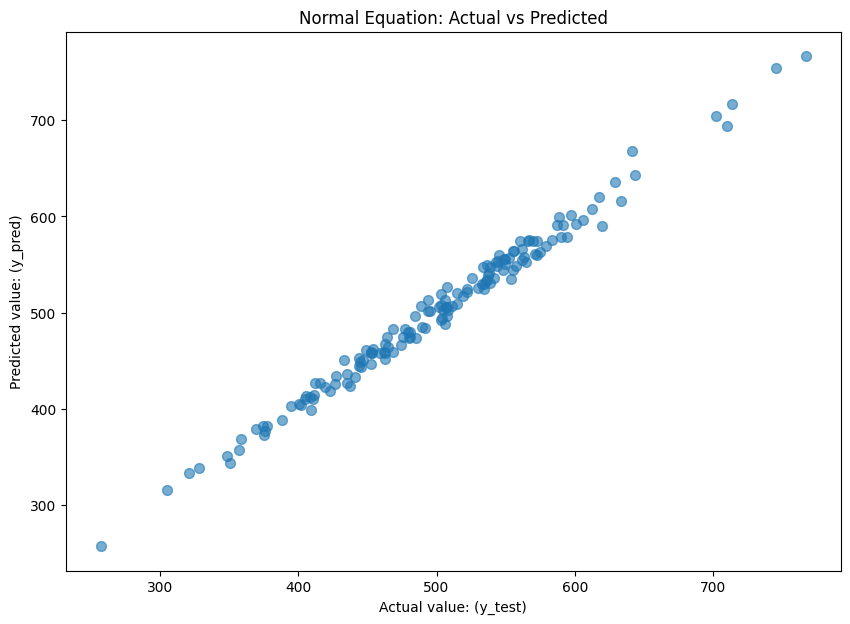

In [ ]:
# bias column
X_test_new = np.c_[np.ones(len(X_test)), X_test]

# Make predictions: X_test * theta
y_pred_normal = X_test_new.dot(theta_best_values)

# flatten to 1d array
y_pred_normal = y_pred_normal.flatten()

# evaluate the model
evaluate_model(y_test, y_pred_normal, model_name="Normal Equation")

### IV. Short answer (markdown): What is the main limitation of the Normal Equation for regression?

The problem is the Time complexity as it takes a long time for large datasets (10K+ rows). It's also a problem if it has incrreased number of features. The large metric operation can cause it to perform slowly.

## G. Batch Gradient Descent [22 pts]
Implement Batch Gradient Descent. To do so, you may use the sample code from the slides. Choose appropriate values for eta and n_iterations so that your theta values converge close to the Normal Equation results. You may refer to [this Google Colab](https://colab.research.google.com/drive/19_UoIFfIBx-nofDFs7Pw7ZB8gVw5yQLe?usp=sharing) for an example.

### I. Implement Batch Gradient Descent and display final theta values. Think about how do they compare to the sklearn LinearRegression coefficients; no need to write about it.

In [ ]:
#from the gradient descendent code sample provided above
# import numpy as np
cost_list = []

X_bgd = np.c_[np.ones(len(X_train)), X_train]
y_bgd = y_train.values.reshape(350, 1)
m = len(X_train)

eta = 0.01
n_iterations = 1000

theta = np.zeros((X_bgd.shape[1], 1)) #here .shape[1] represents the number of columns

for iteration in range(n_iterations):
    y_pred = X_bgd.dot(theta)
    error = y_pred - y_bgd
    gradients = (2.0 / m) * X_bgd.T.dot(error)
    theta = theta - eta * gradients
    cost = np.mean(error ** 2)

    if iteration % (n_iterations // 10) == 0:
        cost_list.append(cost)
        # print(f"Iteration {iteration:4d}: Cost = {cost:.6f}")

print(theta)

[[4.99723116e+02]
 [2.60426511e+01]
 [3.66742566e+01]
 [1.85038730e-01]
 [6.02023605e+01]]


### II. Plot iteration number (x-axis) vs. cost (y-axis) to show convergence.

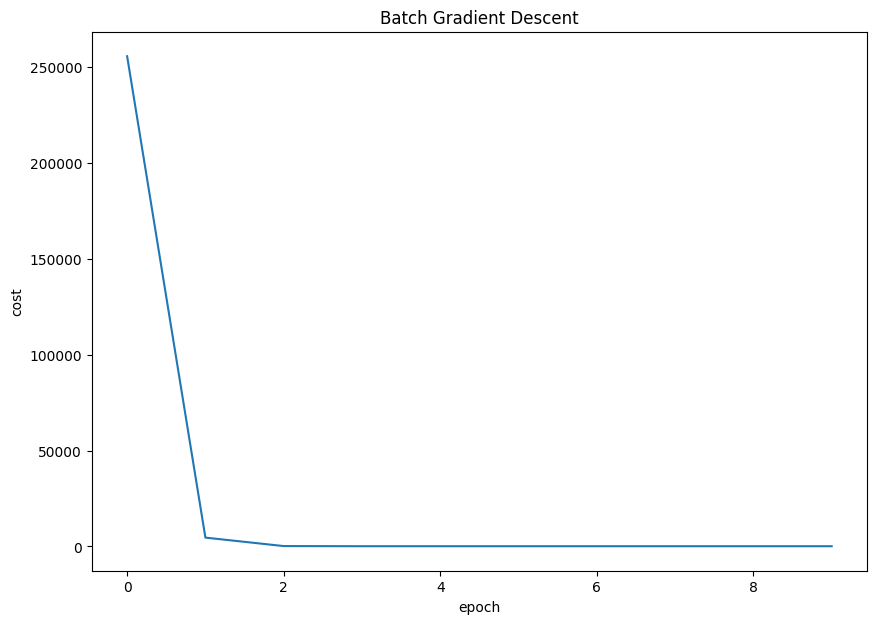

In [ ]:
#from gradient descendant
plt.figure(figsize=(10, 7))
plt.plot(cost_list)
plt.xlabel("epoch")
plt.ylabel("cost")
plt.title("Batch Gradient Descent")
plt.show()

### III. Predict on the test set and call evaluate_model().

MAE: 7.2281
MSE: 79.8130
RMSE: 8.9338
R²: 0.9890


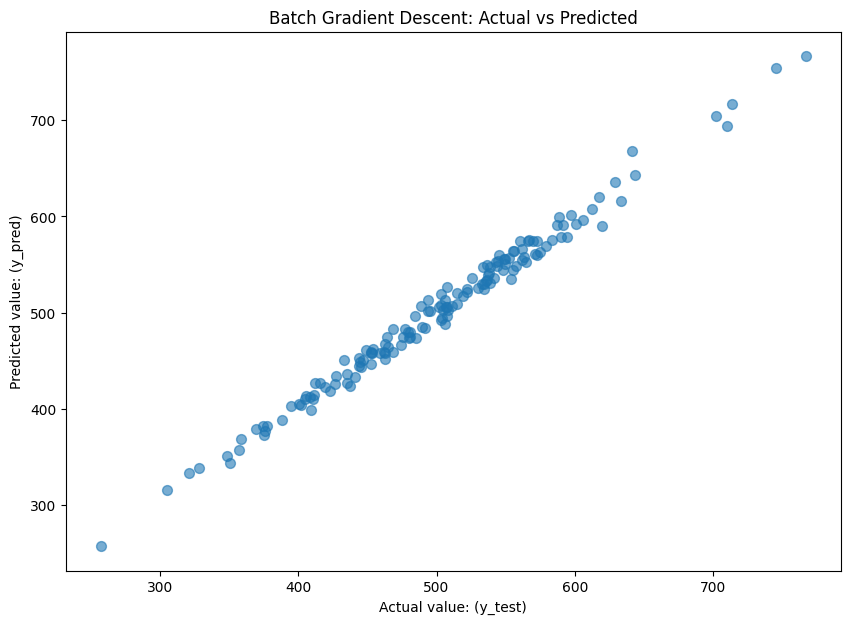

In [ ]:
#assign the predicted to y_pred
X_test_bgd = np.c_[np.ones(len(X_test)), X_test]
y_pred_bgd = X_test_bgd.dot(theta).flatten()

#call our function
evaluate_model(y_test, y_pred_bgd, model_name="Batch Gradient Descent")

### IV. Short answer (markdown): How do derivatives drive the gradient descent update step?

The derivative points in the direction of the increase in steepness in cost function. Steeper the slopev or larger gradient take bigger steps initially. Shallow slope or small gradient take smaller steps at the end.

Without derivatives, we wouldn't know which direction to update θ,
or how far to move.

### V. Short answer (markdown): What are the main benefits and limitations of Batch Gradient Descent?

Main benefit of using Batch Gradient is When the cost function is convex and its slope does not change abruptly (as is the case for the MSE cost function), Batch Gradient Descent with a fixed learning rate will eventually converge to the optimal solution.

The main problem is it uses the whole training set to compute the gradients at every step, which makes it very slow when the training set is large.

## H. Stochastic Gradient Descent [22 pts]
Implement Stochastic Gradient Descent using a learning schedule. You may refer to the slides and [this Google Colab](https://colab.research.google.com/drive/19_UoIFfIBx-nofDFs7Pw7ZB8gVw5yQLe?usp=sharing) for example code. Parameters should be reasonable and theta values should converge close to the Normal Equation.

### I. Implement Stochastic Gradient Descent with a learning schedule and display final theta values. Think about how they compare to the sklearn LinearRegression coefficients; no need to write about it.

In [ ]:
#from the above provided link
X_sgd = np.c_[np.ones(len(X_train)), X_train]
y_sgd = y_train.values.reshape(350, 1)
m = len(X_train)

n_epochs = 50
theta_sgd = np.zeros((X_sgd.shape[1], 1)) #here .shape[1] represents the number of columns
sgd_cost_history = []

#learning schedule parameters
t0, t1 = 5, 50

def learning_schedule(t):
  return t0 / (t + t1)

for epoch in range(n_epochs):
    indices = np.random.permutation(m)
    for i in range(m):
        xi = X_sgd[indices[i:i+1]]
        yi = y_sgd[indices[i:i+1]]

        y_pred_i = xi.dot(theta_sgd)
        error_i = y_pred_i - yi
        gradients = 2 * xi.T.dot(error_i)

        eta = learning_schedule(epoch * m + i)
        theta_sgd = theta_sgd - eta * gradients

    cost = np.mean((X_sgd.dot(theta_sgd) - y_sgd) ** 2)
    sgd_cost_history.append(cost)
    # print(f"Epoch {epoch+1:2d}: Cost = {cost:.6f}")

#display theta value
print(theta_sgd)

[[4.99715654e+02]
 [2.60465243e+01]
 [3.66585924e+01]
 [1.90758265e-01]
 [6.02098713e+01]]


### II. Plot step number (x-axis) vs. cost (y-axis).

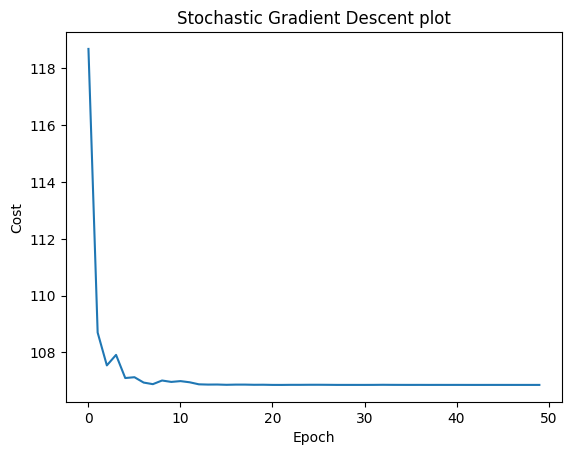

In [ ]:
plt.plot(sgd_cost_history)
plt.title("Stochastic Gradient Descent plot")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()

### III. Predict on the test set and call evaluate_model().

MAE: 7.2301
MSE: 79.8545
RMSE: 8.9361
R²: 0.9890


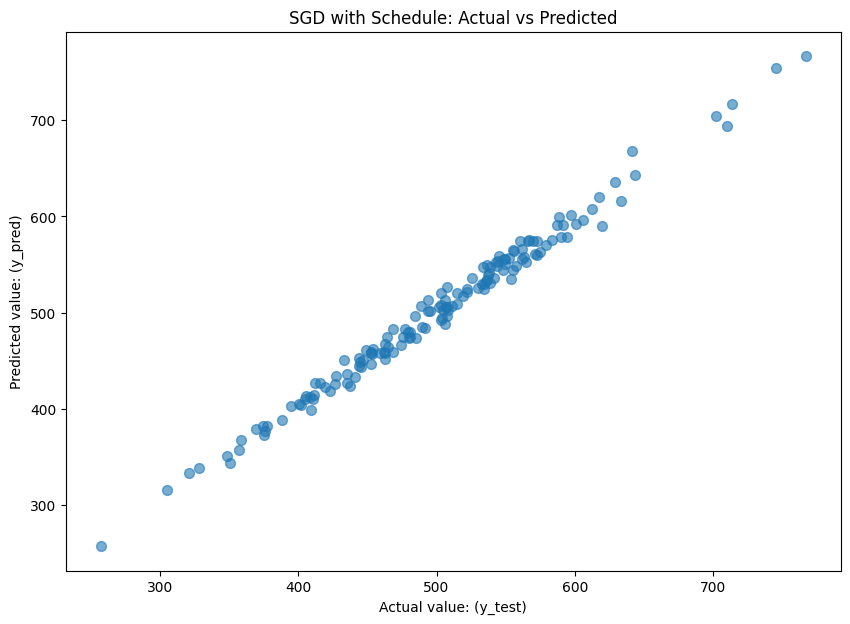

In [ ]:
X_test_sgd = np.c_[np.ones(len(X_test)), X_test]
y_pred_sgd = X_test_sgd.dot(theta_sgd).flatten()
evaluate_model(y_test, y_pred_sgd, model_name="SGD with Schedule")

### IV.Short Question: How do derivatives help in the process of gradient descent?

The derivative helps us to figure out the slope of the cost function at the current theta value. The gradient vector points in the direction of the increase in the steepness of the slope. Thus, to decrease the cost by moving in the opposite direction.

### V. Short answer (markdown): What are the benefits and limitations of Stochastic Gradient Descent?

Stochastic Gradient Descent picks a random instance in the training set at every step and computes the gradients based only on that single instance. Obviously, working on a single instance at a time makes the algorithm much faster because it has very little data to manipulate at every iteration.

However, even if randomness is good to escape from local optima, it is bad because it means that the algorithm can never settle at the minimum

## I. SGDRegressor (sklearn) [12 pts]

### I. Train an SGDRegressor with reasonable max_iter, tol, and learning rate settings so that coefficients are close to the Normal Equation.

In [ ]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(loss='squared_error', max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X_train, y_train)


SGDRegressor(random_state=42)

### II. Display the theta values. Think about how do they compare to the sklearn LinearRegression coefficients; no need to write about it.

In [ ]:
#intercept
print(f"Intercept: {sgd_reg.intercept_[0]:.6f}\n")

#printing the theta values from sgd_reg.coef_ variables
print("Feature Coefficients:")
for feat, coef in zip(feature_names, sgd_reg.coef_):
  print(f"  {feat}: {coef:.6f}")

Intercept: 499.713094

Feature Coefficients:
  Avg_Weekly_Play_Time: 26.045090
  Time_on_Mobile_Client: 36.677414
  Time_on_Desktop_Client: 0.189549
  Years_As_Player: 60.187604


### III. Predict on the test set and call evaluate_model().

MAE: 7.2289
MSE: 79.8191
RMSE: 8.9342
R²: 0.9890


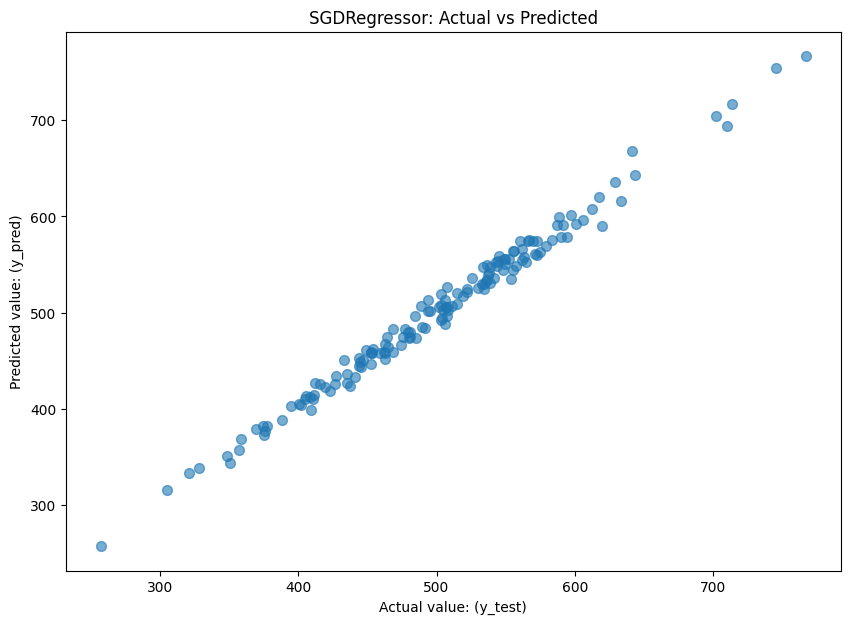

In [ ]:
y_pred_sgdreg = sgd_reg.predict(X_test)
evaluate_model(y_test, y_pred_sgdreg, model_name="SGDRegressor")

## J. Mini-Batch Gradient Descent [3 pts]

### I. Short answer (markdown): How does Mini-Batch Gradient Descent address the limitations of both Batch Gradient Descent and Stochastic Gradient Descent?



1.   In case of large datasets, Mini-Batch Gradient Descent computes the gradients on small random sets of instances called minibatches while Batch Gradient Descent computes the gradients based on the full training. This makes Batch Gradient Descent slow for large datasets.
2.   The algorithm's progress in parameter space is less erratic in Mini-Batch Gradient than with Stochastic Gradient Descent, especially with fairly large mini-
batches.



## K. Polynomial Features — Degree 2 and 3 [15 pts]
Use the original scaled training and test sets as the starting point for both sub-sections below.

### Degree 2:
### I. Apply PolynomialFeatures(degree=2) to the training and test sets.

In [ ]:
#from webcourse
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)

#Use the original scaled training and test sets and transform thwm
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.fit_transform(X_test)
# y_test = poly_features.fit_transform(y_test)

### II. Train a LinearRegression model using the transformed data, generate predictions, and call evaluate_model().

MAE: 7.4322
MSE: 85.3475
RMSE: 9.2384
R²: 0.9882


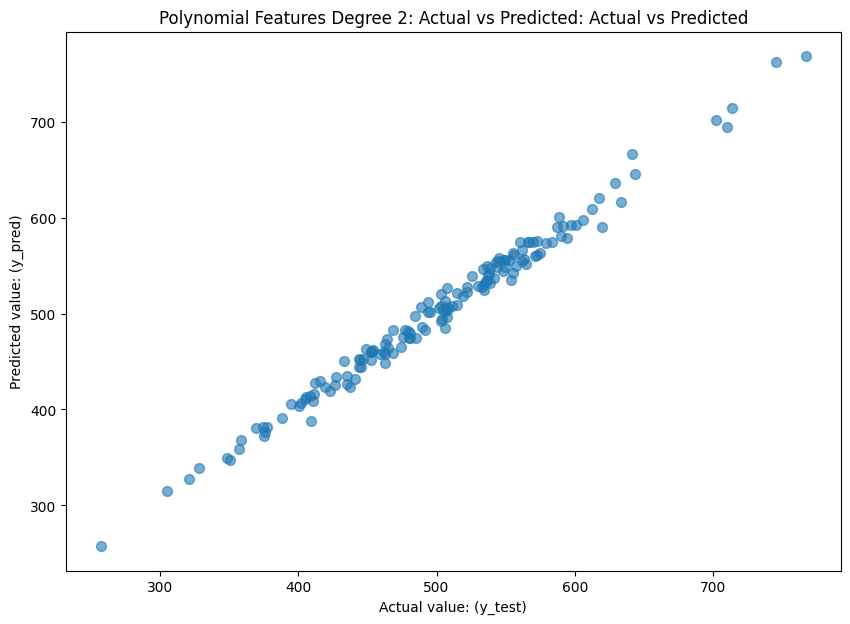

In [ ]:
#training
lr.fit(X_train_poly, y_train)

#predicting
y_pred_poly = lr.predict(X_test_poly)

#call function
evaluate_model(y_test, y_pred_poly, model_name='Polynomial Features Degree 2: Actual vs Predicted')

### Degree 3:
### I. Apply PolynomialFeatures(degree=3) to the training and test sets.

In [ ]:
#do same with different degree
poly_features = PolynomialFeatures(degree=3, include_bias=False)

#Use the original scaled training and test sets and transform thwm
X_train_poly3 = poly_features.fit_transform(X_train)
X_test_poly3 = poly_features.fit_transform(X_test)

### II. Train a LinearRegression model using the transformed data, generate predictions, and call evaluate_model().

MAE: 7.6958
MSE: 94.9689
RMSE: 9.7452
R²: 0.9869


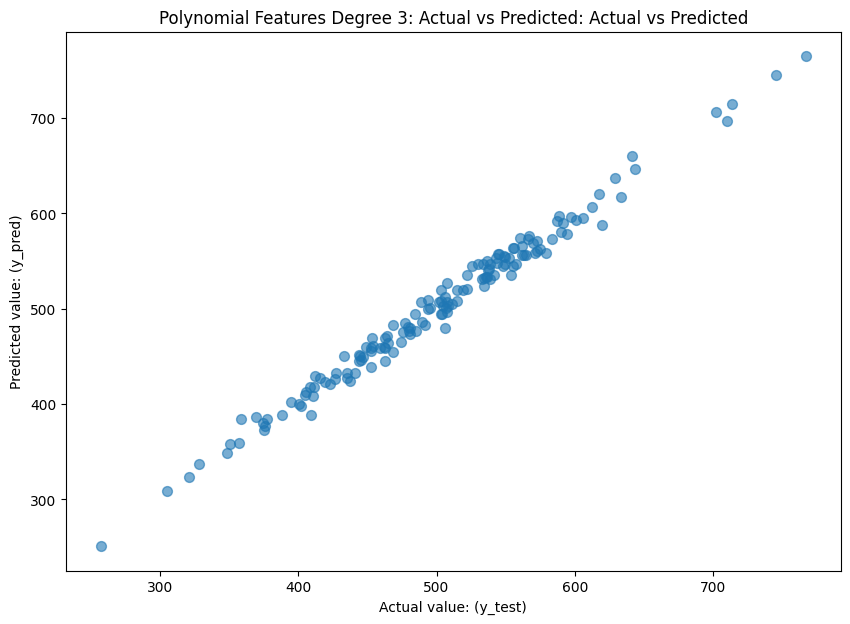

In [ ]:
#training
lr.fit(X_train_poly3, y_train)

#predicting
y_pred_poly3 = lr.predict(X_test_poly3)

#call function
evaluate_model(y_test, y_pred_poly3, model_name='Polynomial Features Degree 3: Actual vs Predicted')

Save the degree-3 polynomial datasets as you will reuse them in Secttions O - Q

In [ ]:
#save the datasets as numpy for easy resuse
np.save('X_train_poly3.npy', X_train_poly3)
np.save('X_test_poly3.npy', X_test_poly3)

## L. Learning Curves [7 pts]

### I. Plot the learning curve for plain LinearRegression.

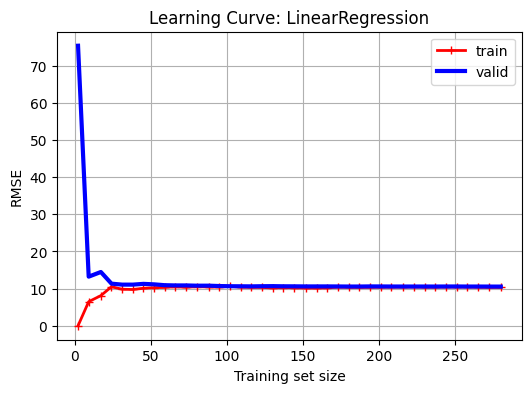

In [ ]:
#from webcourse
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(LinearRegression(), X_train, y_train, train_sizes=np.linspace(0.01, 1.0, 40), cv=5, scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

# extra code – beautifies and saves Figure 4–15
plt.title("Learning Curve: LinearRegression")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")

plt.show()

### II. Plot the learning curve for polynomial regression with degree 5.

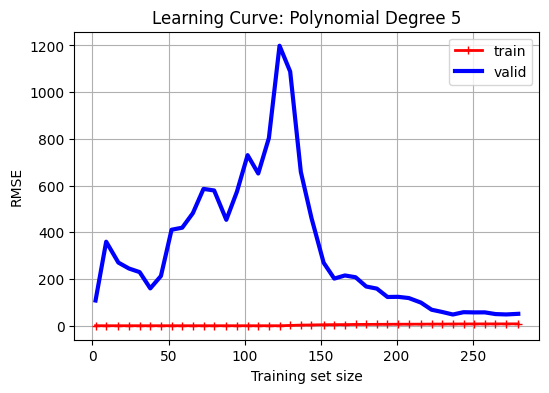

In [ ]:
#from webcourse
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(PolynomialFeatures(degree=5, include_bias=False), LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(polynomial_regression, X_train, y_train, train_sizes=np.linspace(0.01, 1.0, 40), cv=5, scoring="neg_root_mean_squared_error")

# extra code – generates and saves Figure 4–16

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.title("Learning Curve: Polynomial Degree 5")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()

plt.show()

### III. Interpret both curves in a markdown cell.

From section L,I, the learning curve in linearRegression, the trainig error is low while validation error is high and then decreases slowly. This indicates underfitting.

From section L,II the learning curve in polynomial degree of 5, trainig error starts low and stays almost stable. On the other hand, validation error is higher and spikes and then comes closer to the traing error line. The gap between the train and validating error indicates some overfitting.

## M. Regularization [3 pts]

### I. Short answer (markdown): Explain the purpose of regularization.

The purpose of regularisation is to Constrain a model to make it simpler and reduce the risk of overfitting.

## N. Ridge Regression [8 pts]

### I. Train sklearn's Ridge on the degree-3 polynomial data.

In [ ]:
#from webcourse
from sklearn.linear_model import Ridge

#load the numpy data
X_train_poly3_saved = np.load("/content/drive/MyDrive/Colab Notebooks/A2 Linear Models/X_train_poly3.npy")
X_test_poly3_saved = np.load("/content/drive/MyDrive/Colab Notebooks/A2 Linear Models/X_test_poly3.npy")

ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X_train_poly3_saved, y_train)

Ridge(alpha=0.1, solver='cholesky')

### II. Predict and call evaluate_model().

MAE: 7.7050
MSE: 95.1518
RMSE: 9.7546
R²: 0.9869


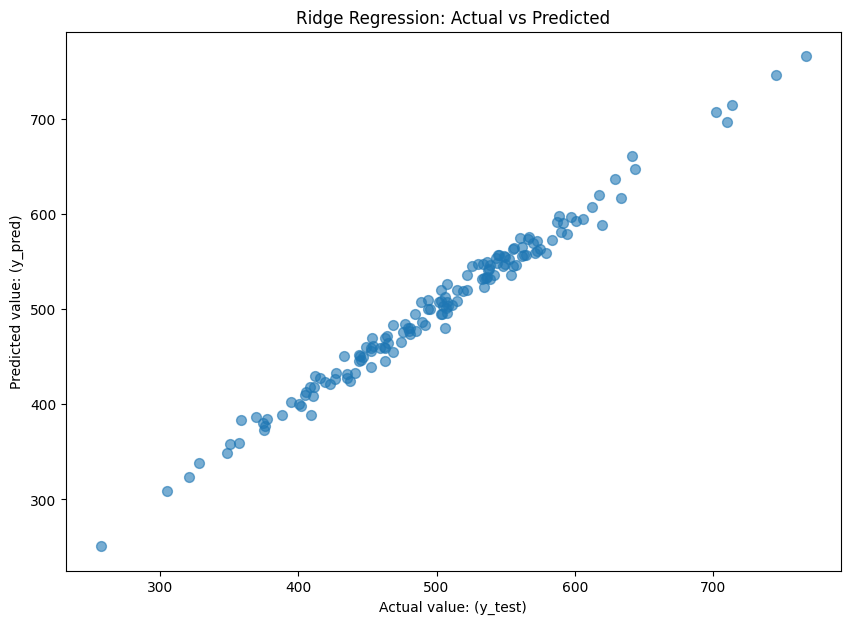

In [ ]:
#predicting
y_pred_ridge = ridge_reg.predict(X_test_poly3_saved)

#evaluate
evaluate_model(y_test, y_pred_ridge, model_name="Ridge Regression")

## O. SGDRegressor for Ridge [8 pts]

### I. Train an SGDRegressor configured for Ridge Regression on the degree-3 polynomial data.

In [ ]:
#from webcourse
sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None, max_iter=1000, eta0=0.01, random_state=101)

sgd_reg.fit(X_train_poly3_saved, y_train)  # y.ravel() because fit() expects 1D targets

SGDRegressor(alpha=0.00028571428571428574, random_state=101, tol=None)

### II. Predict and call evaluate_model().

MAE: 7.9721
MSE: 99.2371
RMSE: 9.9618
R²: 0.9863


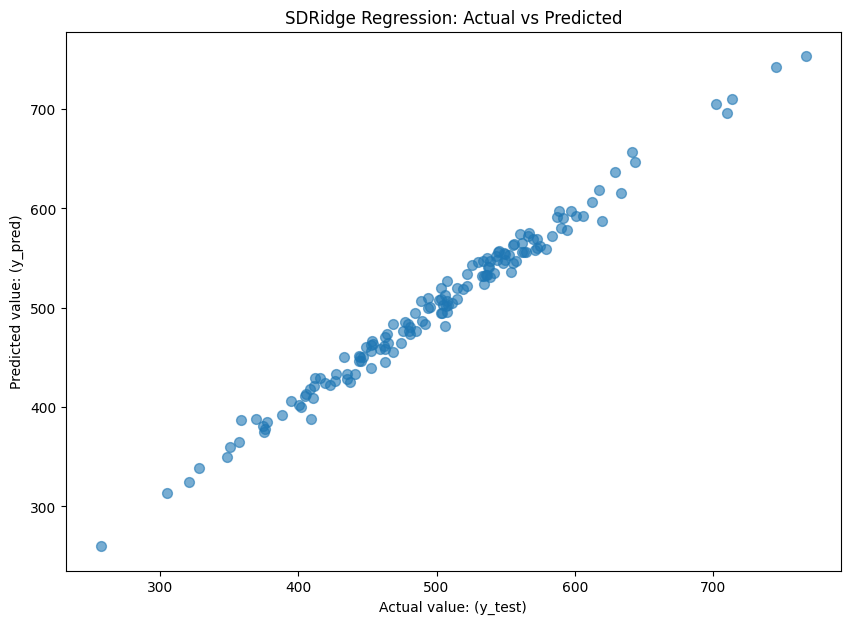

In [ ]:
#predicting
y_pred_sgdRegressor = sgd_reg.predict(X_test_poly3_saved)

#evaluate
evaluate_model(y_test, y_pred_sgdRegressor, model_name="SDRidge Regression")

## P. Lasso Regression [10 pts]

### I. Train sklearn's Lasso on the degree-3 polynomial data.

In [ ]:
#from webcourse
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train_poly3_saved, y_train)

Lasso(alpha=0.1)

### II. Predict and call evaluate_model().

MAE: 7.6828
MSE: 93.1991
RMSE: 9.6540
R²: 0.9872


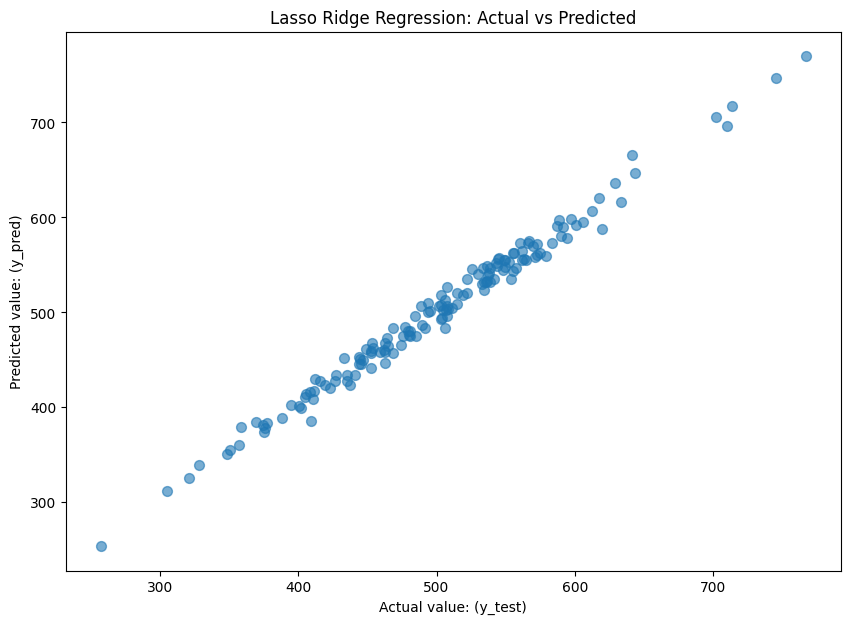

In [ ]:
#predicting
y_pred_lassoRegressor = lasso_reg.predict(X_test_poly3_saved)

#evaluate
evaluate_model(y_test, y_pred_lassoRegressor, model_name="Lasso Ridge Regression")

### III. Short answer (markdown): How does Lasso perform regularization, and what happens to some of the theta values as a result?

Similar to the Ridge Regression, Lasso Regression adds a regularization term to the cost function, but it uses the L1 norm of the weight vector instead of half the square of the L2 norm.

As a result of performing the regulization, the lasso tends to completely eliminate the weights of the least important features (i.e., set them to zero)

## Q. Elastic Net [10 pts]

### I. Train sklearn's ElasticNet on the degree-3 polynomial data.

In [ ]:
#from webcourse
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.05, l1_ratio=0.5)
elastic_net.fit(X_train_poly3_saved, y_train)

ElasticNet(alpha=0.05)

### II. Predict and call evaluate_model().

MAE: 9.3219
MSE: 153.0994
RMSE: 12.3733
R²: 0.9789


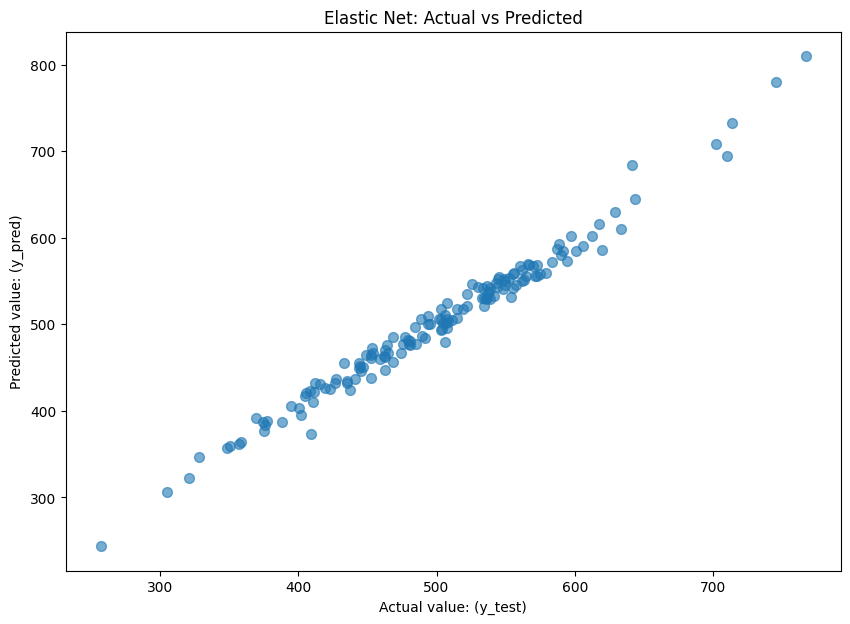

In [ ]:
#predicting
y_pred_elasticNet = elastic_net.predict(X_test_poly3_saved)

#evaluate
evaluate_model(y_test, y_pred_elasticNet, model_name="Elastic Net")

### III. Short answer (markdown): How does ElasticNet perform regularization compared to Ridge and Lasso, and what happens to some of the theta values as a result?

Elastic Net is a middle ground between Ridge Regression and Lasso Regression. The  regularization term in Elastic Net is a simple mix of both Ridge and Lasso's regularization terms, and we can control the mix ratio r. When r = 0, Elastic Net is equivalent to Ridge regression, and when r = 1, it is equivalent to Lasso Regression.

Elastic Net tend to reduce the useless features' weights down to zero. In general, Elastic Net is preferred over Lasso since Lasso may behave erratically when the
number of features is greater than the number of training instances or when several features are strongly correlated.

## R. Bonus Question [4 pts]

In all sections above, we trained our models using scaled feature data. In a real-world scenario, new player data will arrive in its original, unscaled form.

Suppose a new player account has the following feature values:

[35.49726772511229, 12.655651149166752, 39.57766801952616, 4.082620632952961]

These values correspond to Avg_Weekly_Play_Time, Time_on_Mobile_Client, Time_on_Desktop_Client, and Years_As_Player respectively.

Write the code necessary to:

1.	Convert the new record into the correct format for prediction.
2.	Apply the same scaler that was fit on the training data.
3.	Predict the player's Annual_Spending.

This record is very similar to the first training example in the dataset.

In [ ]:
#Using polynomial degree 3 transformation prediction value

#1. Convert the new record into the correct format for prediction.
#store in the form of numpy
new_player_raw = np.array([[35.49726772511229, 12.655651149166752, 39.57766801952616, 4.082620632952961]])
# new_player_raw = new_player_raw.reshape(1,4) #1 sample, 4 features

#2. Scale it
new_player_scaled = scaler.transform(new_player_raw)

#3. Apply predictions
new_player_poly = poly_features.transform(new_player_scaled)
predicted_value = ridge_reg.predict(new_player_poly)

print(f"Predicted Annual Spending value: ${predicted_value[0]:.2f}\n")


Predicted Annual Spending value: $526.11



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
